In [40]:
import pandas as pd
import numpy as np


In [41]:
# Create hours from 0 to 23

hours= list(range(24))

# Number of container operations per hour

operations_per_hour=[
10, 8, 7, 6 , 6 ,8 , 
15 , 25, 35, 45, 
55, 60, 62, 58, 55, 50, 
45, 38, 32, 28, 
22, 18, 15, 12
]

# Energy needed for one container operations 

energy_per_operation_kwh=4.5

# Constant base load of the terminal

base_load_kwh=120

#Estimated solar generation per hour

solar_generation_kwh=[
    0, 0, 0, 0, 0, 0, 
    10, 35, 70, 110,
    150, 180, 200, 190, 160, 120, 
    75, 35, 10,
    0, 0, 0, 0, 0, 
]



In [42]:
print (len(hours))
print(len(operations_per_hour))
print(len(solar_generation_kwh))

24
24
24


In [43]:
df=pd.DataFrame({
    "hour":hours,
    "operations_per_hour":operations_per_hour,
    "energy_per_operation_kwh":energy_per_operation_kwh,
    "base_load_kwh":base_load_kwh,
    "solar_generation_kwh":solar_generation_kwh
})
df

,hour,operations_per_hour,energy_per_operation_kwh,base_load_kwh,solar_generation_kwh
0,0,10,4.5,120,0
1,1,8,4.5,120,0
2,2,7,4.5,120,0
3,3,6,4.5,120,0
4,4,6,4.5,120,0
5,5,8,4.5,120,0
6,6,15,4.5,120,10
7,7,25,4.5,120,35
8,8,35,4.5,120,70
9,9,45,4.5,120,110


In [44]:
df["operational_energy_kwh"]=(
    df["operations_per_hour"]* df["energy_per_operation_kwh"]
)
df["total_demand_kwh"]=(
    df["operational_energy_kwh"] + df["base_load_kwh"]

)
df["grid_usage_kwh"]=np.maximum(
    df["total_demand_kwh"] - df["solar_generation_kwh"],
    0
)
df

,hour,operations_per_hour,energy_per_operation_kwh,base_load_kwh,solar_generation_kwh,operational_energy_kwh,total_demand_kwh,grid_usage_kwh
0,0,10,4.5,120,0,45.0,165.0,165.0
1,1,8,4.5,120,0,36.0,156.0,156.0
2,2,7,4.5,120,0,31.5,151.5,151.5
3,3,6,4.5,120,0,27.0,147.0,147.0
4,4,6,4.5,120,0,27.0,147.0,147.0
5,5,8,4.5,120,0,36.0,156.0,156.0
6,6,15,4.5,120,10,67.5,187.5,177.5
7,7,25,4.5,120,35,112.5,232.5,197.5
8,8,35,4.5,120,70,157.5,277.5,207.5
9,9,45,4.5,120,110,202.5,322.5,212.5


In [45]:
total_demand=df["total_demand_kwh"].sum()
total_solar=df["solar_generation_kwh"].sum()
total_grid=df["grid_usage_kwh"].sum()

total_demand, total_solar, total_grid

(np.float64(6097.5), np.int64(1345), np.float64(4752.5))

In [46]:
solar_contribution= total_solar/ total_demand
grid_dependency=total_grid / total_demand

solar_contribution ,grid_dependency

(np.float64(0.22058220582205823), np.float64(0.7794177941779418))

In [47]:
peak_grid=df["grid_usage_kwh"].max()
peak_hour=df["grid_usage_kwh"].idxmax()

peak_grid, peak_hour

(np.float64(256.0), 17)

In [48]:
def run_scenario(df, scenario_name, operations_factor=1.0, solar_factor=1.0, efficiency_factor=1.0):
    scenario_df = df.copy()
    
    scenario_df["scenario"] = scenario_name
    
    scenario_df["operations_per_hour"] = (
        scenario_df["operations_per_hour"] * operations_factor
    )
    
    scenario_df["solar_generation_kwh"] = (
        scenario_df["solar_generation_kwh"] * solar_factor
    )
    
    scenario_df["energy_per_operation_kwh"] = (
        scenario_df["energy_per_operation_kwh"] * efficiency_factor
    )
    
    scenario_df["operational_energy_kwh"] = (
        scenario_df["operations_per_hour"] * scenario_df["energy_per_operation_kwh"]
    )
    
    scenario_df["total_demand_kwh"] = (
        scenario_df["operational_energy_kwh"] + scenario_df["base_load_kwh"]
    )
    
    scenario_df["grid_usage_kwh"] = np.maximum(
        scenario_df["total_demand_kwh"] - scenario_df["solar_generation_kwh"],
        0
    )
    
    return scenario_df
baseline= run_scenario(df,"Baseline")
baseline.head()


,hour,operations_per_hour,energy_per_operation_kwh,base_load_kwh,solar_generation_kwh,operational_energy_kwh,total_demand_kwh,grid_usage_kwh,scenario
0,0,10.0,4.5,120,0.0,45.0,165.0,165.0,Baseline
1,1,8.0,4.5,120,0.0,36.0,156.0,156.0,Baseline
2,2,7.0,4.5,120,0.0,31.5,151.5,151.5,Baseline
3,3,6.0,4.5,120,0.0,27.0,147.0,147.0,Baseline
4,4,6.0,4.5,120,0.0,27.0,147.0,147.0,Baseline


In [49]:
solar_scenario=run_scenario(
    df,
    "solar +30%",
    solar_factor=1.3
)
solar_scenario.head()

,hour,operations_per_hour,energy_per_operation_kwh,base_load_kwh,solar_generation_kwh,operational_energy_kwh,total_demand_kwh,grid_usage_kwh,scenario
0,0,10.0,4.5,120,0.0,45.0,165.0,165.0,solar +30%
1,1,8.0,4.5,120,0.0,36.0,156.0,156.0,solar +30%
2,2,7.0,4.5,120,0.0,31.5,151.5,151.5,solar +30%
3,3,6.0,4.5,120,0.0,27.0,147.0,147.0,solar +30%
4,4,6.0,4.5,120,0.0,27.0,147.0,147.0,solar +30%


In [50]:
solar_total_demand = solar_scenario["total_demand_kwh"].sum()
solar_total_solar = solar_scenario["solar_generation_kwh"].sum()
solar_total_grid = solar_scenario["grid_usage_kwh"].sum()

solar_contribution = solar_total_solar / solar_total_demand
grid_dependency = solar_total_grid / solar_total_demand

solar_contribution, grid_dependency

(np.float64(0.2867568675686757), np.float64(0.7132431324313243))

In [51]:
efficiency_scenario=run_scenario(
    df,
    "Efficiency +15%",
    efficiency_factor=0.85
)
efficiency_scenario.head()

,hour,operations_per_hour,energy_per_operation_kwh,base_load_kwh,solar_generation_kwh,operational_energy_kwh,total_demand_kwh,grid_usage_kwh,scenario
0,0,10.0,3.825,120,0.0,38.250,158.250,158.250,Efficiency +15%
1,1,8.0,3.825,120,0.0,30.600,150.600,150.600,Efficiency +15%
2,2,7.0,3.825,120,0.0,26.775,146.775,146.775,Efficiency +15%
3,3,6.0,3.825,120,0.0,22.950,142.950,142.950,Efficiency +15%
4,4,6.0,3.825,120,0.0,22.950,142.950,142.950,Efficiency +15%


In [52]:
eff_total_demand = efficiency_scenario["total_demand_kwh"].sum()
eff_total_solar = efficiency_scenario["solar_generation_kwh"].sum()
eff_total_grid = efficiency_scenario["grid_usage_kwh"].sum()

eff_solar_contribution = eff_total_solar / eff_total_demand
eff_grid_dependency = eff_total_grid / eff_total_demand

eff_solar_contribution, eff_grid_dependency

(np.float64(0.23954228722812174), np.float64(0.7604577127718782))

In [53]:
operations_scenario = run_scenario(
    df,
    "Operations +20%",
    operations_factor=1.2
)

operations_scenario.head()

,hour,operations_per_hour,energy_per_operation_kwh,base_load_kwh,solar_generation_kwh,operational_energy_kwh,total_demand_kwh,grid_usage_kwh,scenario
0,0,12.0,4.5,120,0.0,54.0,174.0,174.0,Operations +20%
1,1,9.6,4.5,120,0.0,43.2,163.2,163.2,Operations +20%
2,2,8.4,4.5,120,0.0,37.8,157.8,157.8,Operations +20%
3,3,7.2,4.5,120,0.0,32.4,152.4,152.4,Operations +20%
4,4,7.2,4.5,120,0.0,32.4,152.4,152.4,Operations +20%


In [54]:
ops_total_demand = operations_scenario["total_demand_kwh"].sum()
ops_total_solar = operations_scenario["solar_generation_kwh"].sum()
ops_total_grid = operations_scenario["grid_usage_kwh"].sum()

ops_solar_contribution = ops_total_solar / ops_total_demand
ops_grid_dependency = ops_total_grid / ops_total_demand

ops_solar_contribution, ops_grid_dependency


(np.float64(0.1995252929832369), np.float64(0.800474707016763))

In [55]:
import sqlite3
conn=sqlite3.connect("energy.db")

df.to_sql("energy_data" , conn, if_exists="replace" , index=False)

24

In [56]:
query = """
SELECT 
    SUM(total_demand_kwh) AS total_demand,
    SUM(solar_generation_kwh) AS total_solar,
    SUM(grid_usage_kwh) AS total_grid
FROM energy_data
"""

pd.read_sql(query, conn)

,total_demand,total_solar,total_grid
0,6097.5,1345,4752.5


In [57]:
query = """
SELECT 
    SUM(solar_generation_kwh) / SUM(total_demand_kwh) AS solar_contribution,
    SUM(grid_usage_kwh) / SUM(total_demand_kwh) AS grid_dependency
FROM energy_data
"""

pd.read_sql(query, conn)

,solar_contribution,grid_dependency
0,0.220582,0.779418


In [58]:
query= """
SELECT
    hour,
    grid_usage_kwh
FROM energy_data
ORDER BY grid_usage_kwh DESC
LIMIT 1
"""
pd.read_sql(query, conn)

,hour,grid_usage_kwh
0,17,256.0


In [59]:
query = """
SELECT 
    hour,
    AVG(grid_usage_kwh) AS avg_grid_usage
FROM energy_data
GROUP BY hour
ORDER BY hour
"""

pd.read_sql(query, conn)

,hour,avg_grid_usage
0,0,165.0
1,1,156.0
2,2,151.5
3,3,147.0
4,4,147.0
5,5,156.0
6,6,177.5
7,7,197.5
8,8,207.5
9,9,212.5


## Energy Profile Analysis

This chart shows the relationship between total demand, solar generation, and grid usage throughout the day.


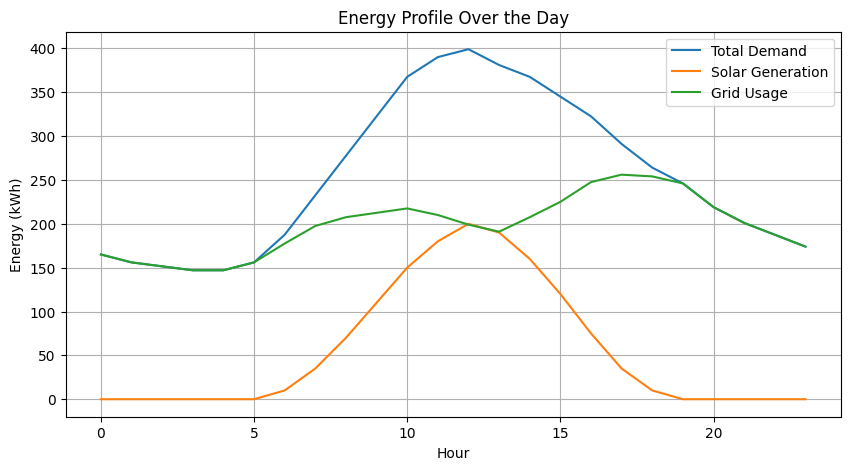

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(df["hour"], df["total_demand_kwh"], label="Total Demand")
plt.plot(df["hour"], df["solar_generation_kwh"], label="Solar Generation")
plt.plot(df["hour"], df["grid_usage_kwh"], label="Grid Usage")

plt.xlabel("Hour")
plt.ylabel("Energy (kWh)")
plt.title("Energy Profile Over the Day")

plt.legend()
plt.grid()

plt.show()

### Key Insights

- Energy demand increases significantly during operational hours, reflecting higher container handling activity.
- Solar generation peaks around midday, providing partial coverage of the total demand.
- Peak grid demand occurs at 17:00, when solar generation declines while demand remains high.
- This indicates a clear mismatch between energy supply (solar) and demand timing.
- As a result, the system remains highly dependent on grid electricity during critical hours.

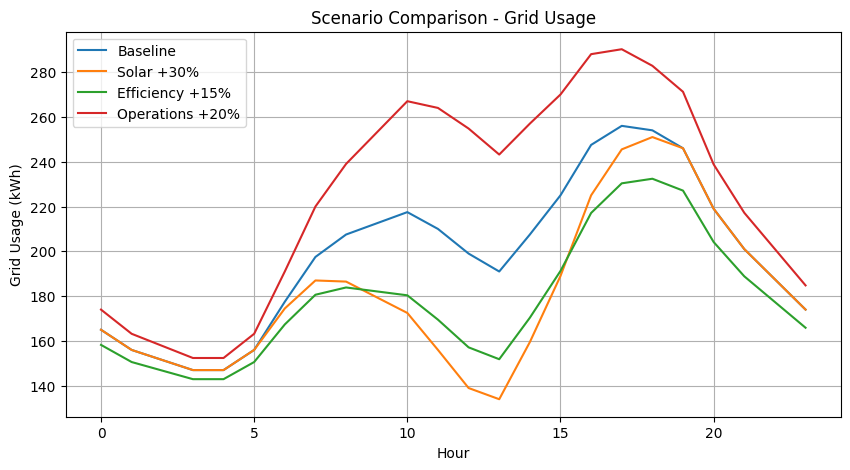

In [61]:
plt.figure(figsize=(10,5))

plt.plot(df["hour"], df["grid_usage_kwh"], label="Baseline")
plt.plot(solar_scenario["hour"], solar_scenario["grid_usage_kwh"], label="Solar +30%")
plt.plot(efficiency_scenario["hour"], efficiency_scenario["grid_usage_kwh"], label="Efficiency +15%")
plt.plot(operations_scenario["hour"], operations_scenario["grid_usage_kwh"], label="Operations +20%")

plt.xlabel("Hour")
plt.ylabel("Grid Usage (kWh)")
plt.title("Scenario Comparison - Grid Usage")

plt.legend()
plt.grid()

plt.show()

### Scenario Comparison Insights

- Increasing operations leads to a significant rise in grid usage across all hours.
- Solar expansion reduces grid dependency during daylight hours but has limited impact during peak demand periods.
- Efficiency improvements provide moderate reductions in energy consumption but are less impactful than solar expansion.
- Peak grid demand remains high in the late afternoon (around 17:00), highlighting a mismatch between energy supply and demand timing.


## Final Recommendation

The analysis shows that increasing solar capacity provides the most significant reduction in grid dependency during daylight hours. However, solar energy alone is not sufficient to address peak demand periods, particularly in the late afternoon when solar generation declines.

Efficiency improvements contribute to reducing overall energy consumption but have a smaller impact compared to solar expansion.

The most critical issue identified is the mismatch between energy supply and demand timing. Peak grid usage occurs when solar generation is low, leading to high reliance on the grid.

### Recommended Actions

- Invest in solar capacity expansion to reduce daytime grid dependency.
- Implement energy efficiency measures to lower overall consumption.
- Introduce energy storage solutions (e.g., batteries) to store excess solar energy for use during peak hours.
- Consider load shifting strategies to move energy-intensive operations closer to peak solar generation periods.


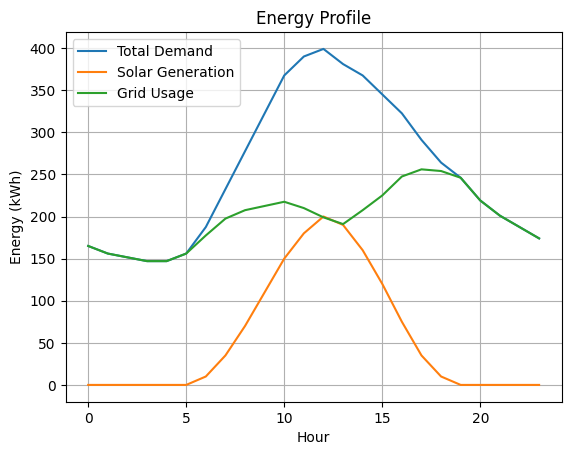

In [62]:
import sqlite3

# Load data
conn = sqlite3.connect("energy.db")
df = pd.read_sql("SELECT * FROM energy_data", conn)

# Show data

df.head()

fig, ax = plt.subplots()

ax.plot(df["hour"], df["total_demand_kwh"], label="Total Demand")
ax.plot(df["hour"], df["solar_generation_kwh"], label="Solar Generation")
ax.plot(df["hour"], df["grid_usage_kwh"], label="Grid Usage")

ax.set_xlabel("Hour")
ax.set_ylabel("Energy (kWh)")
ax.set_title("Energy Profile")
ax.legend()
ax.grid()

df.head()
plt.show()

In [63]:
combined_scenario = run_scenario(
    df,
    "Combined Strategy",
    solar_factor=1.3,
    efficiency_factor=0.85
)

# Load shifting
shift_amount = 8

combined_scenario.loc[combined_scenario["hour"] == 17, "operations_per_hour"] -= shift_amount
combined_scenario.loc[combined_scenario["hour"] == 18, "operations_per_hour"] -= shift_amount

combined_scenario.loc[combined_scenario["hour"] == 12, "operations_per_hour"] += shift_amount
combined_scenario.loc[combined_scenario["hour"] == 13, "operations_per_hour"] += shift_amount

# Recalculate
combined_scenario["operational_energy_kwh"] = (
    combined_scenario["operations_per_hour"] * combined_scenario["energy_per_operation_kwh"]
)

combined_scenario["total_demand_kwh"] = (
    combined_scenario["operational_energy_kwh"] + combined_scenario["base_load_kwh"]
)

combined_scenario["grid_usage_kwh"] = np.maximum(
    combined_scenario["total_demand_kwh"] - combined_scenario["solar_generation_kwh"],
    0
)

combined_scenario.head()


,hour,operations_per_hour,energy_per_operation_kwh,base_load_kwh,solar_generation_kwh,operational_energy_kwh,total_demand_kwh,grid_usage_kwh,scenario
0,0,10.0,3.825,120,0.0,38.250,158.250,158.250,Combined Strategy
1,1,8.0,3.825,120,0.0,30.600,150.600,150.600,Combined Strategy
2,2,7.0,3.825,120,0.0,26.775,146.775,146.775,Combined Strategy
3,3,6.0,3.825,120,0.0,22.950,142.950,142.950,Combined Strategy
4,4,6.0,3.825,120,0.0,22.950,142.950,142.950,Combined Strategy


In [64]:
combined_scenario.loc[
    combined_scenario["hour"].isin([12, 13, 17, 18]),
    ["hour","operations_per_hour", "grid_usage_kwh"]
    ]

,hour,operations_per_hour,grid_usage_kwh
12,12,70.0,127.75
13,13,66.0,125.45
17,17,30.0,189.25
18,18,24.0,198.80


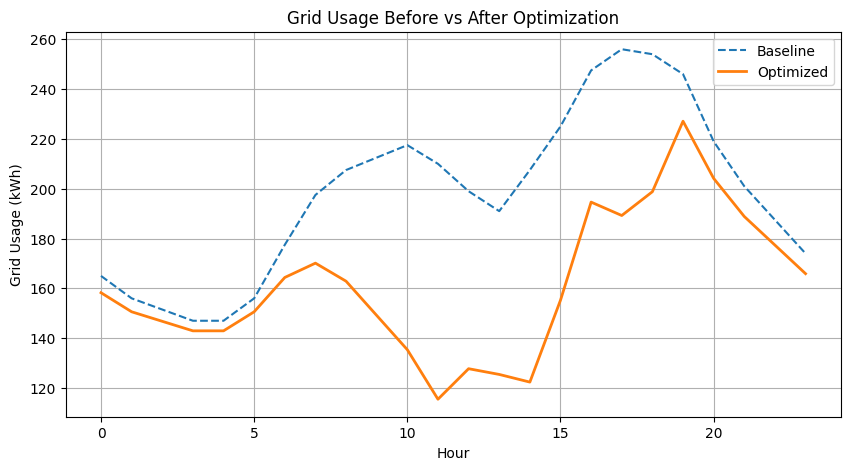

In [65]:
plt.figure(figsize=(10,5))

# Before (Baseline)
plt.plot(df["hour"], df["grid_usage_kwh"], label="Baseline", linestyle="--")

# After (Optimized)
plt.plot(combined_scenario["hour"], combined_scenario["grid_usage_kwh"], label="Optimized", linewidth=2)

plt.xlabel("Hour")
plt.ylabel("Grid Usage (kWh)")
plt.title("Grid Usage Before vs After Optimization")

plt.legend()
plt.grid()

plt.show()


### 🔍 Key Insights

- Peak grid usage occurs in the late afternoon (17–18), when solar generation declines.
- This indicates a mismatch between energy demand and renewable supply.
- Applying a combined strategy (solar expansion + efficiency + load shifting) significantly reduces grid dependency.
- Load shifting moves energy-intensive operations to midday hours where solar energy is available.
- The optimized scenario demonstrates a clear reduction in peak demand pressure on the grid.


### 💡 Recommendations

- Increase solar capacity to better cover daytime operations.
- Implement demand-side management (load shifting) to align operations with solar availability.
- Improve operational efficiency to reduce overall energy consumption.
- Consider battery storage in future work to store excess solar energy for evening use.
